# Clustering Algorithm Comparison on Digits Dataset

Compares DS2LSOM against standard sklearn clustering algorithms using pairwise Rand and Jaccard index (same definition as in the DS2LSOM papers).


In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, HDBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.metrics import pair_confusion_matrix
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from ds2l_som.ds2lsom import DS2LSOM
from dbgsom imo

## Data


In [2]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}, Classes: {len(set(y))}")

Samples: 1797, Features: 64, Classes: 10


## Metrics helper


In [3]:
def pairwise_metrics(y_true, labels):
    """Pairwise Rand and Jaccard index, noise points (label=-1) excluded."""
    mask = labels >= 0
    if mask.sum() < 2:
        return 0.0, 0.0
    tn, fp, fn, tp = pair_confusion_matrix(y_true[mask], labels[mask]).ravel()
    rand = (tp + tn) / (tp + tn + fp + fn)
    jaccard = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    return float(rand), float(jaccard)

## Algorithms


### Algorithm properties

| Algorithm       | Requires n_clusters | Produces noise (−1) | Prototype-based | Density-aware | Topology-preserving |
| --------------- | :-----------------: | :-----------------: | :-------------: | :-----------: | :-----------------: |
| DS2LSOM         |          ✗          |          ✓          |        ✓        |       ✓       |          ✓          |
| KMeans          |          ✓          |          ✗          |        ✓        |       ✗       |          ✗          |
| HDBSCAN         |          ✗          |          ✓          |        ✗        |       ✓       |          ✗          |
| DBSCAN          |          ✗          |          ✓          |        ✗        |       ✓       |          ✗          |
| Agglomerative   |          ✓          |          ✗          |        ✗        |       ✗       |          ✗          |
| GaussianMixture |          ✓          |          ✗          |        ✓        |       ✓       |          ✗          |


## Scalability comparison

Angelehnt an die [sklearn Clustering-Übersicht](https://scikit-learn.org/stable/modules/clustering.html).

Der Engpass von DS2LSOM ist die Distanzmatrix `(k × n)` mit k ≈ 10√n Prototypen —
Laufzeit und Speicher skalieren beide mit **O(n · k) = O(n^1.5)**.

| Algorithm       | Scalability                                             | Parameters                     | Usecase                                                                  | Geometry                         |
| --------------- | ------------------------------------------------------- | ------------------------------ | ------------------------------------------------------------------------ | -------------------------------- |
| **DS2LSOM**     | **Medium `n_samples`**, medium `n_clusters`             | n_prototypes, threshold, sigma | Non-flat geometry, automatic cluster detection, density-based, inductive | Distances between points         |
| KMeans          | Very large `n_samples`, medium `n_clusters` (MiniBatch) | n_clusters                     | Even cluster size, flat geometry, inductive                              | Distances between points         |
| HDBSCAN         | Large `n_samples`, medium `n_clusters`                  | min_cluster_size               | Non-flat geometry, uneven sizes, outlier removal, transductive           | Distances between nearest points |
| DBSCAN          | Very large `n_samples`, medium `n_clusters`             | neighborhood size              | Non-flat geometry, outlier removal, transductive                         | Distances between nearest points |
| Agglomerative   | Large `n_samples` and `n_clusters`                      | n_clusters, linkage            | Many clusters, non-Euclidean distances, transductive                     | Any pairwise distance            |
| GaussianMixture | Not scalable                                            | many                           | Flat geometry, density estimation, inductive                             | Mahalanobis to centers           |

**Hauptbeschränkung von DS2LSOM:** Die Distanzmatrix `weights_ × X` hat Form `(k, n)` und liegt vollständig im Speicher.
Für n = 100 000 und k ≈ 3 162 sind das ~2.4 GB (float64) — damit liegt die praktische Grenze bei **~50 000–100 000 Samples**.
Darüber wäre eine Approximation (z. B. ANN statt exakter Distanzmatrix) nötig.


In [73]:
algorithms = {
    "DS2LSOM": DS2LSOM(
        n_prototypes=100,
        threshold=10,
        method="som",
        model_args={
            "init": {
                "sigma_end": 1.0,
                # "pointer_search": "all",
                "random_state": 42,
                "lambda_": 70,
            }
        },
    ),
    "KMeans": KMeans(n_clusters=10, n_init=10, random_state=42),
    "HDBSCAN": HDBSCAN(min_cluster_size=20),
    "DBSCAN": DBSCAN(eps=2.5, min_samples=5),
    "Agglomerative": AgglomerativeClustering(n_clusters=10),
    "GaussianMixture": GaussianMixture(n_components=10, random_state=42),
}

## Benchmark


In [74]:
results = []
all_labels = {}

for name, model in algorithms.items():
    t0 = time.perf_counter()
    if hasattr(model, "fit_predict"):
        labels = model.fit_predict(X)
    else:
        model.fit(X)
        labels = model.predict(X)
    elapsed = time.perf_counter() - t0

    labels = np.array(labels)
    rand, jaccard = pairwise_metrics(y, labels)
    n_clusters = len(set(labels[labels >= 0]))
    n_noise = int((labels == -1).sum())

    results.append(
        dict(
            Algorithm=name,
            Clusters=n_clusters,
            Noise=n_noise,
            Rand=rand,
            Jaccard=jaccard,
            Runtime_s=elapsed,
        )
    )
    all_labels[name] = labels
    print(
        f"{name:<18} clusters={n_clusters:2d}  noise={n_noise:4d}  rand={rand:.3f}  jaccard={jaccard:.3f}  t={elapsed:.2f}s"
    )

df = pd.DataFrame(results).set_index("Algorithm")
df.style.format(
    {"Rand": "{:.3f}", "Jaccard": "{:.3f}", "Runtime_s": "{:.2f}"}
).background_gradient(subset=["Rand", "Jaccard"], cmap="Greens")

DS2LSOM            clusters= 8  noise=  85  rand=0.899  jaccard=0.448  t=0.22s
KMeans             clusters=10  noise=   0  rand=0.906  jaccard=0.415  t=0.06s


f:\Dokumente\git\ds2l-som\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


HDBSCAN            clusters= 6  noise=1244  rand=0.991  jaccard=0.950  t=0.29s
DBSCAN             clusters= 2  noise=1756  rand=1.000  jaccard=1.000  t=0.01s
Agglomerative      clusters=10  noise=   0  rand=0.930  jaccard=0.542  t=0.12s
GaussianMixture    clusters=10  noise=   0  rand=0.906  jaccard=0.427  t=0.26s


,Clusters,Noise,Rand,Jaccard,Runtime_s
Algorithm,,,,,
DS2LSOM,8,85,0.899,0.448,0.22
KMeans,10,0,0.906,0.415,0.06
HDBSCAN,6,1244,0.991,0.950,0.29
DBSCAN,2,1756,1.000,1.000,0.01
Agglomerative,10,0,0.930,0.542,0.12
GaussianMixture,10,0,0.906,0.427,0.26


## Comparison plots


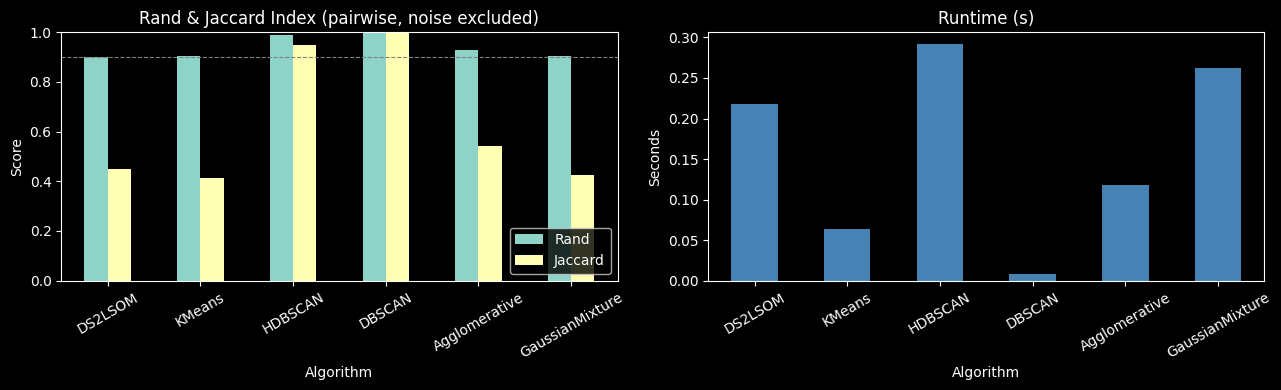

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[["Rand", "Jaccard"]].plot(kind="bar", ax=axes[0], ylim=(0, 1), rot=30)
axes[0].set_title("Rand & Jaccard Index (pairwise, noise excluded)")
axes[0].set_ylabel("Score")
axes[0].axhline(0.9, color="gray", linewidth=0.8, linestyle="--")
axes[0].legend(loc="lower right")

df["Runtime_s"].plot(kind="bar", ax=axes[1], color="steelblue", rot=30)
axes[1].set_title("Runtime (s)")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

## t-SNE visualization


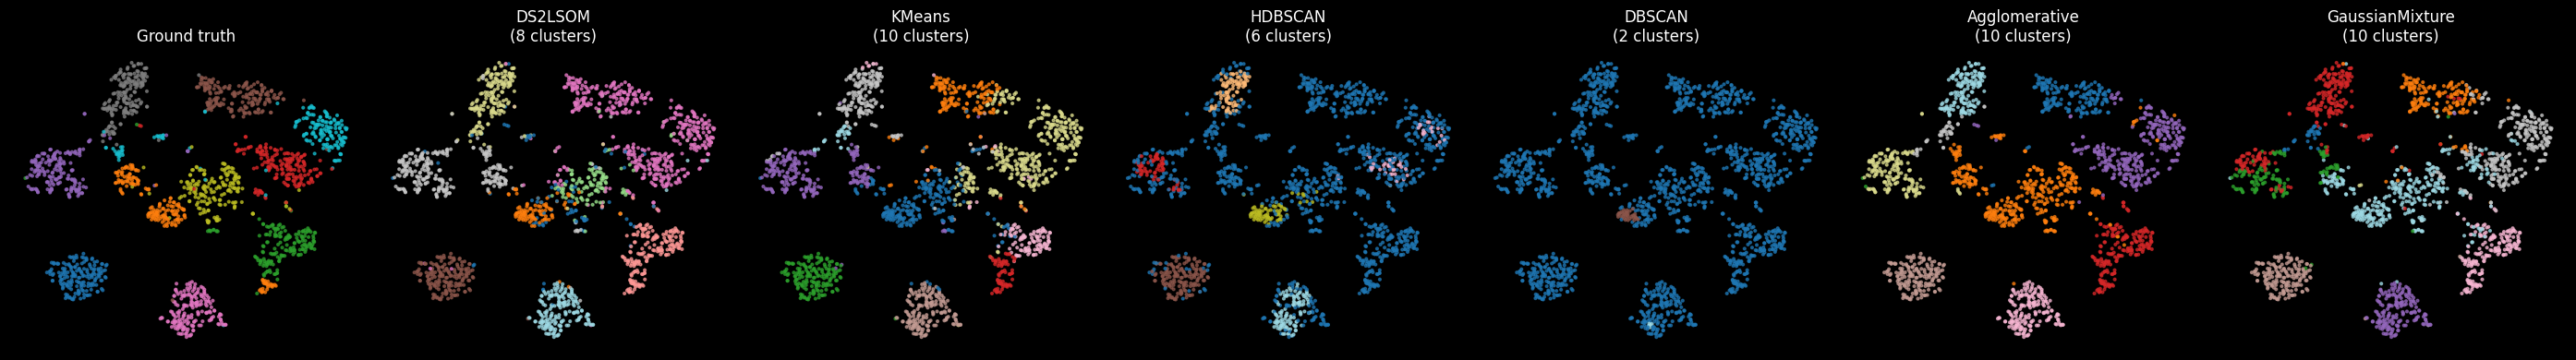

In [76]:
embedding = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)

names = list(algorithms.keys())
n_cols = len(names) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

axes[0].scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="tab10", s=4, alpha=0.7)
axes[0].set_title("Ground truth")
axes[0].axis("off")

for ax, name in zip(axes[1:], names):
    labels = all_labels[name]
    n_clusters = len(set(labels[labels >= 0]))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab20", s=4, alpha=0.7)
    ax.set_title(f"{name}\n({n_clusters} clusters)")
    ax.axis("off")

plt.tight_layout()
plt.show()

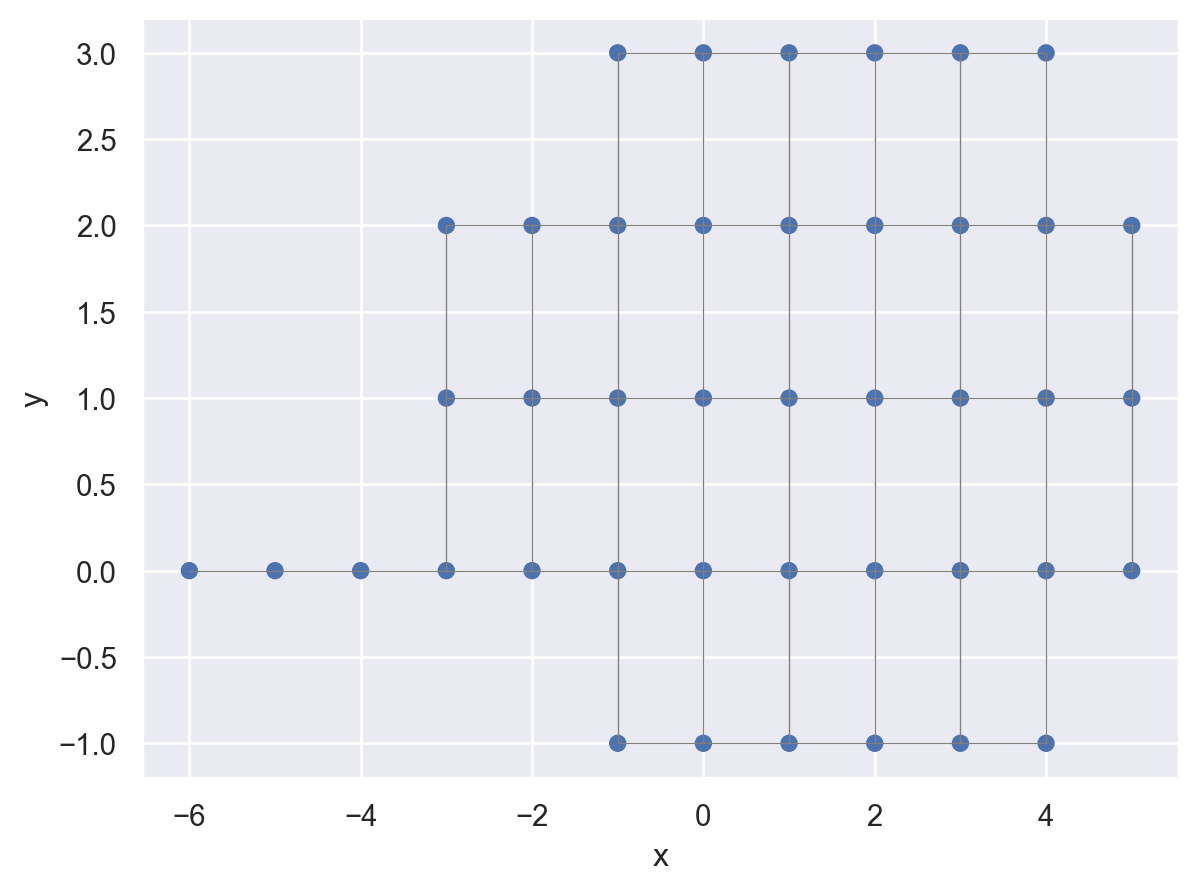

In [77]:
algorithms["DS2LSOM"].quantizer_.plot()